# Claude utilization vs. token usage

Checks, visually, whether Anthropic's reported `five_hour` / `seven_day`
utilization percentage is a **linear** function of token usage - and
whether raw token counts or dollar-cost-weighted tokens (the hypothesis
from [claudecodecamp.com](https://www.claudecodecamp.com/p/i-tried-to-reverse-engineer-claude-code-s-usage-limits),
tested against official pricing) track it more closely. See this
project's `README.md` for background and the "what is cache" explainer.

**Run `python3 ~/opt/claude-utilization-cost-tracker/recompute_token_events.py`
before running this notebook**, so `token-events.jsonl` reflects
everything up to now (it's not kept incrementally - see the README).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/Users/jeanlescut/opt/claude-utilization-cost-tracker/data"

# Toggle this to flip which axis is which in every plot below - a linear
# relationship stays linear either way, this is purely about which
# orientation is easier to eyeball.
SWAP_AXES = False

## Pricing model

Official per-model API pricing (`platform.claude.com/docs/en/about-claude/pricing`,
confirmed 2026-08-24) plus the uniform prompt-cache multipliers, applied
relative to each model's own input price. This is the "dollar_cost"
hypothesis being tested - see the README's cache explainer for what the
cache fields mean.

In [2]:
# $ / MTok, confirmed live from platform.claude.com/docs/en/about-claude/pricing
PRICING = {
    "claude-opus-5": {"in": 5, "out": 25},
    "claude-sonnet-5": {"in": 2, "out": 10},
    "claude-haiku-4-5-20251001": {"in": 1, "out": 5},
}
# Cache multipliers relative to a model's own base input price - uniform
# across models (same official pricing page).
CACHE_READ_MULT = 0.1
CACHE_WRITE_5M_MULT = 1.25
CACHE_WRITE_1H_MULT = 2.0


def dollar_cost(row):
    """Exact $ cost of one event, using the real 5m/1h cache-write split -
    None for a model not in PRICING (e.g. "<synthetic>" placeholder
    entries), which the plots below then simply skip."""
    price = PRICING.get(row["model"])
    if price is None:
        return None
    u = row["usage"]
    in_p, out_p = price["in"] / 1e6, price["out"] / 1e6
    cost = u.get("input_tokens", 0) * in_p + u.get("output_tokens", 0) * out_p
    cost += u.get("cache_read_input_tokens", 0) * in_p * CACHE_READ_MULT
    cc = u.get("cache_creation") or {}
    cost += cc.get("ephemeral_5m_input_tokens", 0) * in_p * CACHE_WRITE_5M_MULT
    cost += cc.get("ephemeral_1h_input_tokens", 0) * in_p * CACHE_WRITE_1H_MULT
    return cost


def raw_tokens(row):
    """Unweighted sum of every token field - input + output + cache
    creation + cache read, all counted equally regardless of type."""
    u = row["usage"]
    return (u.get("input_tokens", 0) + u.get("output_tokens", 0)
            + u.get("cache_read_input_tokens", 0) + u.get("cache_creation_input_tokens", 0))

## Load the two logs

In [3]:
def load_token_events(path):
    l_rows = []
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            if not e.get("ts") or not e.get("model"):
                continue  # unparseable timestamp, or a non-usage entry
            l_rows.append({"ts": pd.Timestamp(e["ts"], unit="s", tz="UTC"),
                            "model": e["model"], "usage": e["usage"]})
    return pd.DataFrame(l_rows)


# limits[].kind -> the legacy top-level block reporting the same limit.
KIND_TO_KEY = {"session": "five_hour", "weekly_all": "seven_day"}


def load_util_log(path):
    """Rows before 2026-08-26 lack api_headers/have extra fields
    (token_deltas/baseline) - irrelevant here, since only the `api` block
    (same shape in every schema version) is used.

    Reads both the legacy top-level blocks and the newer `limits[]` array.
    `limits[].percent` has never once disagreed with the matching top-level
    `utilization` (0 disagreements across all 284 payloads logged so far),
    so the percentage still comes from the legacy field; what `limits[]`
    adds that the flat blocks don't carry is `severity` and `is_active`.
    """
    l_rows = []
    with open(path) as f:
        for line in f:
            r = json.loads(line)
            api = r.get("api")
            if not api:
                continue  # failed fetch that run - no reading to use
            row = {"ts": pd.Timestamp(r["ts"], unit="s", tz="UTC")}
            for key in ("five_hour", "seven_day"):
                b = api.get(key)
                row[f"{key}_pct"] = b["utilization"] if b else None
                # resets_at is null whenever *no window is currently open*
                # (an idle gap), not only on a failed fetch - see the
                # window-detection cell below.
                row[f"{key}_resets_at"] = pd.Timestamp(b["resets_at"]) if b and b.get("resets_at") else pd.NaT
            for lim in api.get("limits") or []:
                key = KIND_TO_KEY.get(lim.get("kind"))
                if key is None:
                    continue  # a limit kind that didn't exist when this was written
                row[f"{key}_severity"] = lim.get("severity")
                row[f"{key}_is_active"] = lim.get("is_active")
            l_rows.append(row)
    return pd.DataFrame(l_rows)


df_events = load_token_events(f"{DATA_DIR}/token-events.jsonl")
df_events["dollar_cost"] = df_events.apply(dollar_cost, axis=1)
df_events["raw_tokens"] = df_events.apply(raw_tokens, axis=1)

df_util = load_util_log(f"{DATA_DIR}/utilization-log.jsonl")

print(f"{len(df_events)} token events, {df_events['ts'].min()} to {df_events['ts'].max()}")
print(f"{len(df_util)} utilization readings, {df_util['ts'].min()} to {df_util['ts'].max()}")


14758 token events, 2026-07-30 13:38:59+00:00 to 2026-08-27 11:22:15+00:00
337 utilization readings, 2026-08-24 15:59:02+00:00 to 2026-08-27 11:25:53+00:00


## Payload surface: does the API ever just *tell* us the answer?

Every limit block in the response carries `limit_dollars`, `used_dollars`
and `remaining_dollars`, and the `spend` block carries a genuine money
type (`{amount_minor, currency, exponent}`). Their mere existence is the
strongest structural hint that the meter really is denominated in dollars
- but on this account they are all null, because they're gated behind the
paid "usage credits" feature (`spend.enabled`,
`extra_usage.credits_ever_enabled`, `spend.can_purchase_credits` - all
false).

If any of them ever populates, the dollar-cost hypothesis stops being a
hypothesis: the backend would be handing over its own numbers directly,
and the whole correlation exercise in this notebook becomes unnecessary.
So this cell is a standing tripwire - re-run it whenever new data comes
in, rather than assuming nothing changed.


In [4]:
DOLLAR_FIELDS = ("limit_dollars", "used_dollars", "remaining_dollars")
GATES = (("spend", "enabled"), ("spend", "can_purchase_credits"),
         ("extra_usage", "is_enabled"), ("extra_usage", "credits_ever_enabled"))


def payload_surface_report(path):
    """Scans the raw log for (a) any non-null dollar/credit figure and
    (b) the feature gates that would have to flip for one to appear."""
    n = 0
    hits = {}                      # "block.field" -> first value seen
    gates = {f"{b}.{f}": set() for b, f in GATES}
    keys_seen = {}                 # top-level key -> first iso it appeared
    for line in open(path):
        r = json.loads(line)
        api = r.get("api")
        if not api:
            continue
        n += 1
        for k in api:
            keys_seen.setdefault(k, r["iso"])
        for block, val in api.items():
            if not isinstance(val, dict):
                continue
            for f in DOLLAR_FIELDS:
                if val.get(f) is not None:
                    hits.setdefault(f"{block}.{f}", (r["iso"], val[f]))
            # spend.used is a money object, not a scalar - non-zero means real spend
            used = val.get("used")
            if isinstance(used, dict) and used.get("amount_minor"):
                hits.setdefault(f"{block}.used", (r["iso"], used))
        for b, f in GATES:
            blk = api.get(b)
            if isinstance(blk, dict):
                gates[f"{b}.{f}"].add(blk.get(f))
    print(f"scanned {n} payloads\n")
    print("feature gates (values ever observed):")
    for k, v in gates.items():
        print(f"  {k:38} {sorted(v, key=str)}")
    print("\ndollar / credit figures:")
    if hits:
        for k, (iso, v) in hits.items():
            print(f"  *** POPULATED *** {k} first at {iso}: {v!r}")
        print("\n  -> The API is now reporting real money. Stop inferring the")
        print("     budget from correlation and read these fields directly.")
    else:
        print("  all null in every payload - still gated, nothing to read yet.")
    return keys_seen


keys_seen = payload_surface_report(f"{DATA_DIR}/utilization-log.jsonl")
print(f"\ntop-level keys present ({len(keys_seen)}):")
print("  " + ", ".join(keys_seen))


scanned 337 payloads

feature gates (values ever observed):
  spend.enabled                          [False]
  spend.can_purchase_credits             [False]
  extra_usage.is_enabled                 [False]
  extra_usage.credits_ever_enabled       [False]

dollar / credit figures:
  all null in every payload - still gated, nothing to read yet.

top-level keys present (17):
  five_hour, seven_day, seven_day_oauth_apps, seven_day_opus, seven_day_sonnet, seven_day_cowork, seven_day_omelette, tangelo, iguana_necktie, omelette_promotional, nimbus_quill, cinder_cove, amber_ladder, extra_usage, limits, spend, member_dashboard_available


### What `limits[]` adds

`limits[]` has been in the payload since the very first poll (it is not a
new field). It mirrors the legacy top-level blocks' percentage exactly,
but adds two things they don't carry: `severity` (the banner Claude Code
shows) and `is_active` (which limit is currently the governing one -
exactly one of the two is true in every payload observed).

Severity thresholds can only be *bracketed* from observed data, not read
off directly, since we only see the values our own usage happened to
produce.


In [5]:
def severity_summary(df_util):
    for key, label in (("five_hour", "session"), ("seven_day", "weekly_all")):
        sev_col, act_col, pct_col = f"{key}_severity", f"{key}_is_active", f"{key}_pct"
        if sev_col not in df_util:
            print(f"{key}: no limits[] data"); continue
        d = df_util.dropna(subset=[sev_col])
        print(f"\n{key}  (limits[].kind == {label!r}, {len(d)} readings)")
        for sev, g in d.groupby(sev_col):
            print(f"    severity {sev:9} observed at {g[pct_col].min():5.1f}-{g[pct_col].max():5.1f}%"
                  f"   (n={len(g)})")
        if act_col in d:
            frac = d[act_col].mean()
            print(f"    is_active: true in {frac:.0%} of readings")

severity_summary(df_util)

# is_active should be mutually exclusive across the two limits
if "five_hour_is_active" in df_util and "seven_day_is_active" in df_util:
    both = df_util.dropna(subset=["five_hour_is_active", "seven_day_is_active"])
    n_exclusive = (both["five_hour_is_active"].astype(bool)
                   ^ both["seven_day_is_active"].astype(bool)).sum()
    print(f"\nexactly one limit is_active in {n_exclusive}/{len(both)} readings"
          f" -> is_active marks the currently governing limit"
          if n_exclusive == len(both) else
          f"\n!! is_active NOT mutually exclusive in {len(both)-n_exclusive} readings - re-examine")



five_hour  (limits[].kind == 'session', 337 readings)
    severity critical  observed at 100.0-100.0%   (n=20)
    severity normal    observed at   0.0- 71.0%   (n=317)
    is_active: true in 74% of readings

seven_day  (limits[].kind == 'weekly_all', 337 readings)
    severity normal    observed at   0.0- 24.0%   (n=304)
    severity warning   observed at  79.0- 81.0%   (n=33)
    is_active: true in 26% of readings

exactly one limit is_active in 337/337 readings -> is_active marks the currently governing limit


## Detect reset windows

`resets_at` is a fixed boundary set when a window is created (not a
continuously-rolling "+5h from now") - consecutive readings that report
the *same* `resets_at` all belong to one window. Grouping (clustering)
those readings finds each window's boundary.

A window's `start` is `end - span`. It is **not** the previous window's
end: `five_hour` windows are *activity-triggered*, not contiguous. A new
one opens on the first message sent after the last one expired, so
between them there are genuine idle gaps where the API reports
`resets_at: null, utilization: 0.0` and no window exists at all. All four
gaps observed so far ran 0.3h-13.7h, so chaining `start = prev_end` would
have back-dated a window's start by up to ~13.7 hours and swept unrelated
events into it. (It happened to make no numerical difference here, because
an idle gap is idle precisely *because* nothing was sent during it - all
four contain exactly 0 token events - but the rule is wrong in principle
and would bite the moment usage arrives from another client.)

`seven_day` is different: it *is* a fixed rolling schedule, so there
`end - span` and `prev_end` agree to within a minute anyway.

The **last** window for each limit is very likely still open (its
`resets_at` is a future boundary Claude Code hasn't actually reached
yet) - its "peak so far" isn't a final number, unlike the earlier ones.


In [6]:
def detect_windows(df_util, key, span):
    s_resets = df_util[f"{key}_resets_at"].dropna().sort_values().unique()
    if len(s_resets) == 0:
        return []
    s_resets = pd.to_datetime(s_resets)
    clusters = [[s_resets[0]]]
    for t in s_resets[1:]:
        if (t - clusters[-1][-1]) < pd.Timedelta(minutes=5):
            clusters[-1].append(t)
        else:
            clusters.append([t])
    l_windows = []
    for i, c in enumerate(clusters):
        end = c[-1]
        rows = df_util[f"{key}_resets_at"].isin(c)
        l_windows.append({
            "start": end - span,  # NOT prev_end - windows aren't contiguous
            "end": end,
            "peak_pct": df_util.loc[rows, f"{key}_pct"].max(),
            "worst_severity": (df_util.loc[rows, f"{key}_severity"].dropna().iloc[-1]
                               if f"{key}_severity" in df_util and rows.any()
                                  and df_util.loc[rows, f"{key}_severity"].notna().any()
                               else None),
            "is_open": i == len(clusters) - 1,
        })
    return l_windows


fh_windows = detect_windows(df_util, "five_hour", pd.Timedelta(hours=5))
sd_windows = detect_windows(df_util, "seven_day", pd.Timedelta(days=7))
print(f"five_hour: {len(fh_windows)} windows ({sum(not w['is_open'] for w in fh_windows)} closed)")
print(f"seven_day: {len(sd_windows)} windows ({sum(not w['is_open'] for w in sd_windows)} closed)")
for w in fh_windows:
    print(f"  five_hour {w['start']:%m-%d %H:%M} -> {w['end']:%m-%d %H:%M}  "
          f"peak {w['peak_pct']:5.1f}% {w['worst_severity'] or '':8} "
          f"{'OPEN' if w['is_open'] else 'closed'}")


five_hour: 6 windows (5 closed)
seven_day: 2 windows (1 closed)
  five_hour 08-24 14:20 -> 08-24 19:20  peak  53.0% normal   closed
  five_hour 08-25 07:30 -> 08-25 12:30  peak  13.0% normal   closed
  five_hour 08-25 14:10 -> 08-25 19:10  peak  41.0% normal   closed
  five_hour 08-26 08:50 -> 08-26 13:50  peak 100.0% critical closed
  five_hour 08-26 14:10 -> 08-26 19:10  peak  71.0% normal   closed
  five_hour 08-27 11:19 -> 08-27 16:19  peak  16.0% normal   OPEN


## Build each window's trajectory and plot

For every utilization reading inside a window, pair it with the
cumulative token metric (raw count, or $ cost) accumulated *up to that
moment* within the same window. Each window becomes one line; several
lines on one axes is the "does every window follow the same slope" check
- and whether each individual line looks straight is the linearity
check.

In [7]:
def window_trajectory(df_events, df_util, window, metric_col, pct_col):
    ev = df_events[(df_events["ts"] >= window["start"]) & (df_events["ts"] < window["end"])].sort_values("ts")
    ev = ev.dropna(subset=[metric_col])
    ev = ev.assign(cum=ev[metric_col].cumsum())
    polls = df_util[(df_util["ts"] >= window["start"]) & (df_util["ts"] <= window["end"])].sort_values("ts")
    polls = polls.dropna(subset=[pct_col])
    merged = pd.merge_asof(polls[["ts", pct_col]], ev[["ts", "cum"]], on="ts", direction="backward")
    merged["cum"] = merged["cum"].fillna(0.0)
    return merged


def plot_windows(ax, windows, metric_col, pct_col, title, xlabel, scale=1.0, swap=SWAP_AXES):
    cmap = plt.get_cmap("tab10")
    for i, w in enumerate(windows):
        traj = window_trajectory(df_events, df_util, w, metric_col, pct_col)
        if traj.empty:
            continue
        x, y = traj["cum"] / scale, traj[pct_col]
        if swap:
            x, y = y, x
        label = f"{w['end'].date()} {'(open, so far)' if w['is_open'] else '(closed)'} - peak {w['peak_pct']:.0f}%"
        ax.plot(x, y, marker="o", markersize=3, color=cmap(i % 10), label=label)
    if swap:
        ax.set_xlabel("utilization %")
        ax.set_ylabel(xlabel)
    else:
        ax.set_xlabel(xlabel)
        ax.set_ylabel("utilization %")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

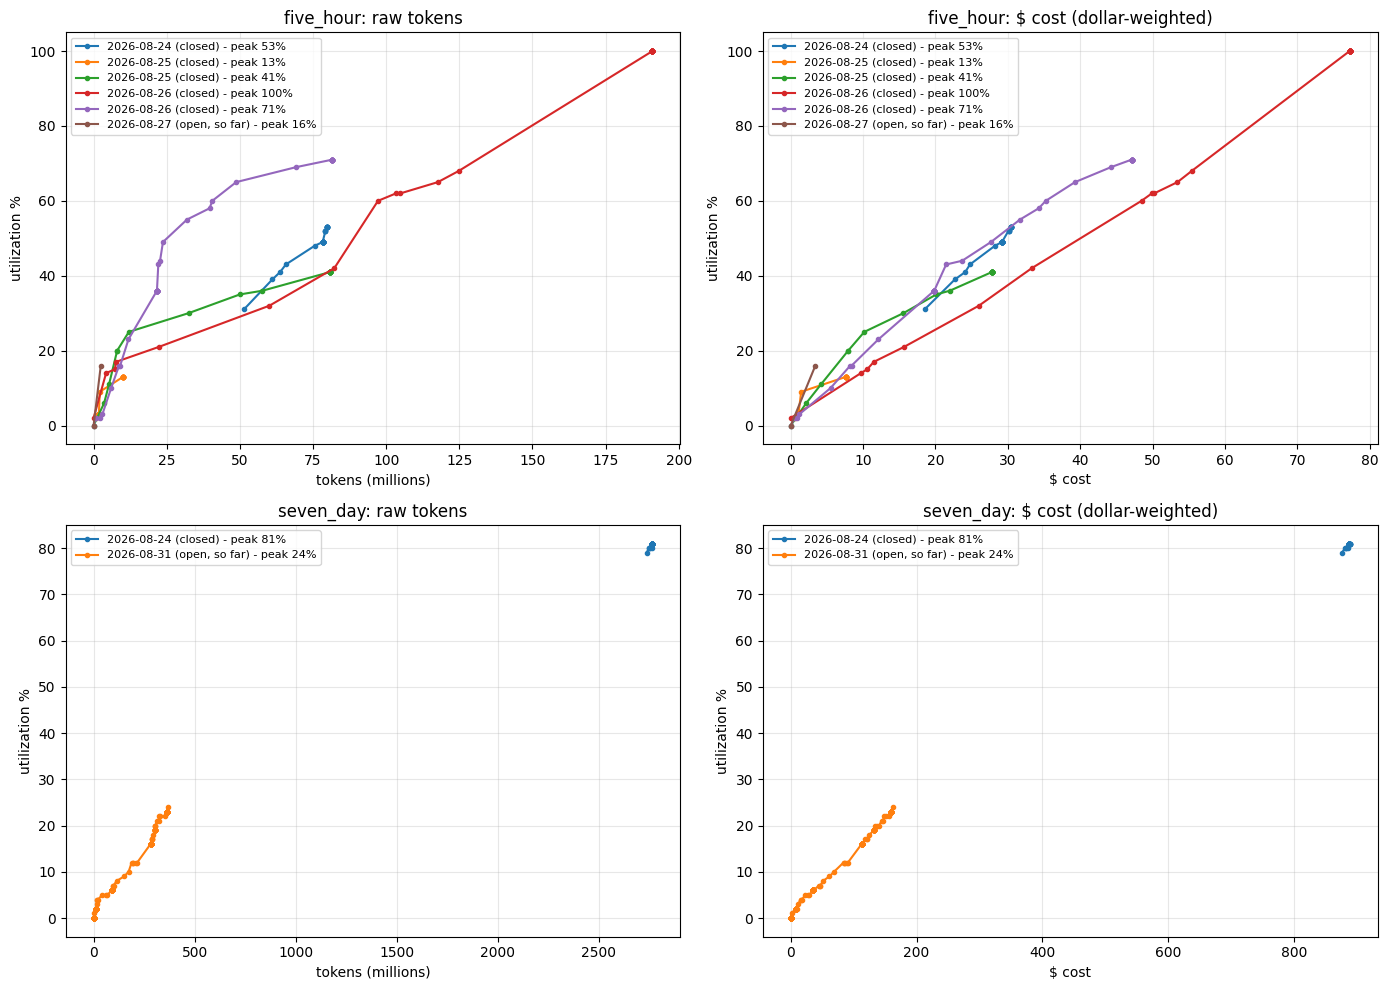

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_windows(axes[0][0], fh_windows, "raw_tokens", "five_hour_pct",
             "five_hour: raw tokens", "tokens (millions)", scale=1e6)
plot_windows(axes[0][1], fh_windows, "dollar_cost", "five_hour_pct",
             "five_hour: $ cost (dollar-weighted)", "$ cost")
plot_windows(axes[1][0], sd_windows, "raw_tokens", "seven_day_pct",
             "seven_day: raw tokens", "tokens (millions)", scale=1e6)
plot_windows(axes[1][1], sd_windows, "dollar_cost", "seven_day_pct",
             "seven_day: $ cost (dollar-weighted)", "$ cost")

fig.tight_layout()
plt.show()

**What to look for**: does each line look straight (linear within a
window)? Do different windows' lines have roughly the same slope (a
stable "budget" - $ or tokens per percentage point) - and is that
slope more consistent in the raw-tokens view or the $-cost view? A
consistent slope across windows in one view but not the other is
evidence for (or against) that view's weighting hypothesis.

## Swapped-axes view

Same data, `SWAP_AXES = True` - X = utilization %, Y = tokens/cost used.
Toggle the `SWAP_AXES` variable near the top of the notebook and re-run
if you'd rather have every plot in this orientation by default.

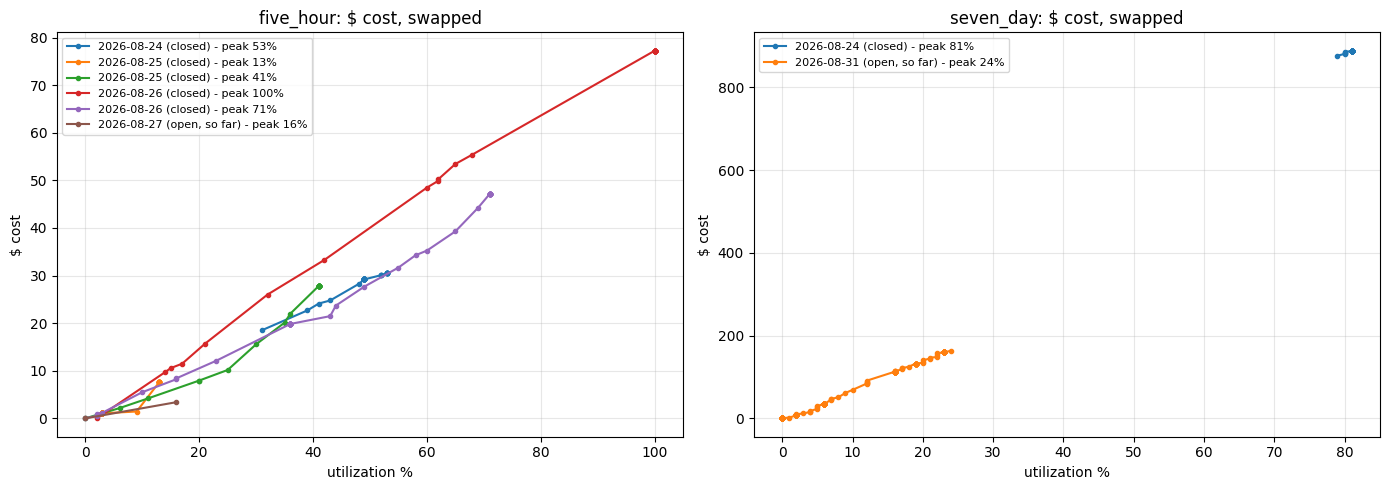

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_windows(axes[0], fh_windows, "dollar_cost", "five_hour_pct",
             "five_hour: $ cost, swapped", "$ cost", swap=True)
plot_windows(axes[1], sd_windows, "dollar_cost", "seven_day_pct",
             "seven_day: $ cost, swapped", "$ cost", swap=True)
fig.tight_layout()
plt.show()

---

# Quantitative test

Everything above is descriptive. This section does the actual measurement,
and supersedes the earlier "the implied budget differs 40% between
windows" reading — which turned out to be an artefact of using cumulative
totals. Read this section before drawing conclusions from the plots above.

## Step 1: do the two meters agree with each other?

This is the test that needs no cost model at all, and it is the one that
settles what varies.

Both meters watch the same token stream at the same time. Whatever
Anthropic's internal weighted-usage unit `W` is, over the same interval:

$$\Delta_{5h}\% = 100\,\frac{W}{B_{5h}} \qquad
  \Delta_{7d}\% = 100\,\frac{W}{B_{7d}}$$

so their **ratio cancels `W` entirely**:

$$\frac{\Delta_{5h}\%}{\Delta_{7d}\%} = \frac{B_{7d}}{B_{5h}}$$

That makes the ratio blind to *how* tokens are priced. If it stays
constant, the two allowances are in fixed proportion and neither is being
throttled — so any apparent variation in "dollars per percentage point"
has to come from our cost model, not from a moving budget. If the ratio
moves, a budget genuinely changed.


In [10]:
def meter_ratio_segments(df_util):
    """Maximal runs where BOTH meters are non-decreasing (i.e. no reset in
    either) and the 5h meter hasn't saturated. Within such a run, both
    meters observed the same usage, so their ratio is B_7d / B_5h."""
    df_p = df_util.dropna(subset=["five_hour_pct", "seven_day_pct"]).sort_values("ts")
    l_seg, l_cur = [], []
    for _, r in df_p.iterrows():
        if l_cur:
            prev = l_cur[-1]
            # a drop in either meter = a reset; >=100 = saturated, can't rise further
            if (r["five_hour_pct"] < prev["five_hour_pct"]
                    or r["seven_day_pct"] < prev["seven_day_pct"]
                    or prev["five_hour_pct"] >= 100):
                l_seg.append(l_cur); l_cur = []
        l_cur.append(r)
    if l_cur:
        l_seg.append(l_cur)

    l_out = []
    for seg in l_seg:
        a, b = seg[0], seg[-1]
        d5 = b["five_hour_pct"] - a["five_hour_pct"]
        d7 = b["seven_day_pct"] - a["seven_day_pct"]
        if d5 <= 0 or d7 <= 0:
            continue
        s_in = (df_events["ts"] >= a["ts"]) & (df_events["ts"] < b["ts"])
        l_out.append({"from": a["ts"], "to": b["ts"], "d_5h": d5, "d_7d": d7,
                      "cost": df_events.loc[s_in, "dollar_cost"].sum(),
                      "ratio_5h_per_7d": d5 / d7,
                      # 7d quantised to whole %, so a d_7d of 2 carries ~+-25%
                      "quantisation_err_pct": 100 * 0.5 / d7})
    return pd.DataFrame(l_out)


df_ratio = meter_ratio_segments(df_util)
print(df_ratio[["from", "d_5h", "d_7d", "cost", "ratio_5h_per_7d",
                "quantisation_err_pct"]].to_string(index=False,
      formatters={"from": lambda t: f"{t:%m-%d %H:%M}"}, float_format=lambda v: f"{v:8.2f}"))

s_ratio = df_ratio["ratio_5h_per_7d"]
# weight by d_7d: segments with a bigger 7d move are far less quantisation-noisy
ratio_w = (df_ratio["ratio_5h_per_7d"] * df_ratio["d_7d"]).sum() / df_ratio["d_7d"].sum()
print(f"\nB_7d / B_5h  =  {ratio_w:.2f}   (d_7d-weighted mean; unweighted "
      f"{s_ratio.mean():.2f}, range {s_ratio.min():.2f}-{s_ratio.max():.2f})")
print(f"-> one 7-day percentage point is worth about {ratio_w:.1f} five-hour points.")


       from     d_5h     d_7d     cost  ratio_5h_per_7d  quantisation_err_pct
08-24 15:59    22.00     2.00    11.99            11.00                 25.00
08-24 19:26    13.00     2.00     7.63             6.50                 25.00
08-25 12:35    41.00     4.00    27.82            10.25                 12.50
08-25 19:17   100.00    10.00    77.24            10.00                  5.00
08-26 13:50    71.00     7.00    47.11            10.14                  7.14
08-26 19:14    16.00     1.00     3.40            16.00                 50.00

B_7d / B_5h  =  10.12   (d_7d-weighted mean; unweighted 10.65, range 6.50-16.00)
-> one 7-day percentage point is worth about 10.1 five-hour points.


**Reading it.** The ratio sits near ~10 in every segment with enough 7-day
movement to be meaningful. Crucially that includes the 08-24 segment,
which ran while the *weekly* meter was at 79–81% (`warning` severity) —
the same ratio as segments running at 6–16% weekly.

So the 5-hour allowance is **not** reduced when the weekly allowance is
nearly exhausted. That kills the weekly-throttle hypothesis, which was
the leading explanation for the apparent between-window differences.

The low outlier is the segment where the 7-day meter moved only 2 points:
at that size a ±0.5 point rounding error is ±25%, so it carries almost no
information. The `quantisation_err_pct` column makes that explicit.

## Step 2: increments, never cumulative totals

The earlier "implied budget" numbers divided a window's *cumulative* cost
by its *cumulative* utilization. That is the wrong unit of observation and
it is what produced the phantom 40% between-window spread:

- **Fake sample size.** Consecutive cumulative readings share all of their
  history, so 284 poll rows are nowhere near 284 independent observations.
  Regressing on them gives R² near 1 and meaningless confidence intervals.
- **A per-window offset that never washes out.** If the meter lags usage
  even slightly, cost accumulated near the window start is misattributed.
  Every later cumulative ratio inherits that same offset — which is
  exactly why the implied budget looked *stable within* a window and
  *different between* windows. It was one offset per window, not a
  changing budget.

The fix is to use the **change between two consecutive polls** as the unit
of observation. That differences the offset away.


In [11]:
def token_parts(usage):
    """Pull the components out of a raw usage dict, keeping thinking tokens
    SEPARATE from the rest of output - thinking_tokens is a *subset* of
    output_tokens, so entering both as-is would double-count them."""
    cc = usage.get("cache_creation") or {}
    think = (usage.get("output_tokens_details") or {}).get("thinking_tokens", 0)
    return pd.Series({
        "output_tokens": usage.get("output_tokens", 0),
        "thinking_tokens": think,
        "cache_read_tokens": usage.get("cache_read_input_tokens", 0),
        "cache_write_tokens": cc.get("ephemeral_5m_input_tokens", 0)
                              + cc.get("ephemeral_1h_input_tokens", 0),
    })


df_events = df_events.join(df_events["usage"].apply(token_parts))
METRICS = ["dollar_cost", "raw_tokens", "output_tokens", "thinking_tokens",
           "cache_read_tokens", "cache_write_tokens"]


def build_increments(pct_col):
    """One row per consecutive poll pair where `pct_col` rose inside a single
    window. Rows where the meter has saturated at 100% are dropped: it
    cannot rise further there, so usage stops being observable."""
    df_p = df_util.dropna(subset=[pct_col]).sort_values("ts").reset_index(drop=True)
    l_rows = []
    for i in range(len(df_p) - 1):
        a, b = df_p.iloc[i], df_p.iloc[i + 1]
        if b[pct_col] <= a[pct_col] or a[pct_col] >= 100:
            continue                       # reset, no movement, or saturated
        s_in = (df_events["ts"] >= a["ts"]) & (df_events["ts"] < b["ts"])
        n = int(s_in.sum())
        if not n:
            continue                       # meter rose with no local event: see below
        d_row = {"ts": a["ts"], "d_pct": b[pct_col] - a[pct_col], "n_requests": n}
        for m in METRICS:
            d_row[m] = df_events.loc[s_in, m].sum()
        l_rows.append(d_row)
    return pd.DataFrame(l_rows)


def fit_through_origin(x, y):
    """No usage must mean no utilization, so the line goes through (0,0).
    Returns (slope, R^2)."""
    slope = (x @ y) / (x @ x)
    return slope, 1 - ((y - slope * x) ** 2).sum() / ((y - y.mean()) ** 2).sum()


df_inc = build_increments("five_hour_pct")
print(f"{len(df_inc)} independent intervals where the 5h meter rose\n")
print(f"{'predictor':<22}{'R2':>10}{'slope':>14}")
for m in ["n_requests"] + METRICS:
    slope, r2 = fit_through_origin(df_inc[m].to_numpy(float), df_inc["d_pct"].to_numpy(float))
    print(f"  {m:<20}{r2:10.4f}{slope:14.4g}")


46 independent intervals where the 5h meter rose

predictor                     R2         slope
  n_requests              0.4958        0.1188
  dollar_cost             0.7680         1.359
  raw_tokens              0.2780     4.432e-07
  output_tokens           0.5717      9.88e-05
  thinking_tokens         0.5141     0.0001643
  cache_read_tokens       0.2225     4.436e-07
  cache_write_tokens      0.1793     1.096e-05


**This is the headline result.** Dollar-weighted cost predicts the meter
far better than a raw token count does — the gap is not marginal. Raw
tokens treat a cache read (0.1× price) the same as an output token (5×
the input price for Sonnet), and the data plainly rejects that.

This is the first *quantitative* support for the dollar-cost hypothesis in
this project; everything before it was visual inspection of a handful of
window trajectories.

Two honest caveats before the budget estimate:

- **`n_requests` alone scores respectably.** That is not an independent
  finding — bigger intervals contain both more requests and more dollars.
  The test that matters is whether adding a per-request term to the cost
  model *improves* it, which is checked below. It barely does, so there is
  no evidence for a meaningful fixed per-request charge.
- Reasoning effort cannot be tested at all: 100% of events on this account
  are `effort: "high"`, so its coefficient is unidentifiable. Anthropic's
  own docs say effort matters; we simply cannot measure it from this data.


In [12]:
# Does a fixed per-request charge add anything on top of $ cost?
a_X = df_inc[["n_requests", "dollar_cost"]].to_numpy(float)
a_y = df_inc["d_pct"].to_numpy(float)
a_c, *_ = np.linalg.lstsq(a_X, a_y, rcond=None)
r2_both = 1 - ((a_y - a_X @ a_c) ** 2).sum() / ((a_y - a_y.mean()) ** 2).sum()
_, r2_cost = fit_through_origin(df_inc["dollar_cost"].to_numpy(float), a_y)
print(f"$ cost alone           R2 = {r2_cost:.4f}")
print(f"$ cost + per-request   R2 = {r2_both:.4f}   (+{r2_both - r2_cost:.4f})")
print(f"  fitted: {a_c[0]:.4f} pp/request + {a_c[1]:.4f} pp/$")
print("  -> the per-request term buys almost nothing; treat the meter as $-driven.\n")


def budget_estimate(pct_col, label, n_boot=5000):
    """Full-scale budget = 100 / (pp per dollar), with a bootstrap CI over
    intervals - the honest uncertainty, given how few there are."""
    df_i = build_increments(pct_col)
    x = df_i["dollar_cost"].to_numpy(float); y = df_i["d_pct"].to_numpy(float)
    slope, r2 = fit_through_origin(x, y)
    rng = np.random.default_rng(0)
    # slope only here - a resample can have zero variance in y, which makes the
    # R^2 term divide by zero. The CI needs the slope, not the fit quality.
    a_idx = rng.integers(0, len(x), (n_boot, len(x)))
    a_boot = np.array([100 / ((x[i] @ y[i]) / (x[i] @ x[i])) for i in a_idx])
    lo, hi = np.percentile(a_boot, [2.5, 97.5])
    print(f"{label}: n={len(x)}  R2={r2:.4f}  slope={slope:.4f} pp/$")
    print(f"   full budget ~ ${100 / slope:,.2f}   95% CI [${lo:,.2f}, ${hi:,.2f}]")
    return 100 / slope


b_5h = budget_estimate("five_hour_pct", "5-hour")
b_7d = budget_estimate("seven_day_pct", "7-day")
print(f"\nratio from these two fits: {b_7d / b_5h:.1f}x")
print(f"ratio from the weighting-free meter test above: {ratio_w:.1f}x")
print("The meter-ratio number is the more trustworthy of the two: it needs no")
print("cost model, and the 7-day fit has few intervals and coarse quantisation.")


$ cost alone           R2 = 0.7680
$ cost + per-request   R2 = 0.7683   (+0.0003)
  fitted: 0.0042 pp/request + 1.3185 pp/$
  -> the per-request term buys almost nothing; treat the meter as $-driven.

5-hour: n=46  R2=0.7680  slope=1.3593 pp/$
   full budget ~ $73.57   95% CI [$66.32, $83.27]
7-day: n=22  R2=0.3724  slope=0.1656 pp/$
   full budget ~ $603.77   95% CI [$516.42, $718.21]

ratio from these two fits: 8.2x
ratio from the weighting-free meter test above: 10.1x
The meter-ratio number is the more trustworthy of the two: it needs no
cost model, and the 7-day fit has few intervals and coarse quantisation.


## What this means, and how to predict a future window

**The budget does not vary.** The two meters stay in constant proportion
across every segment, including one that ran with the weekly meter at
79–81%. Combined with a single dollar-cost fit that explains most of the
variance, the earlier "$58 in one window, $81 in another" reading is best
understood as a per-window attribution offset in the cumulative method,
not a real change in allowance.

So predicting a future window needs no model of a moving budget:

- **A 5-hour window is worth roughly the estimate above in
  API-equivalent spend**, and that is stable window to window. Use the CI,
  not the point estimate — with this many intervals the honest answer is a
  range.
- **The weekly allowance is about `ratio_w`× a single 5-hour window**, so
  saturating every 5-hour window is not sustainable across a week: the
  weekly cap binds first. That ratio is the number to plan against, and it
  is the most robust quantity here because it needs no cost model.
- **To sanity-check the estimate live**, watch the two meters early in a
  window. Their ratio should land near `ratio_w`; the dollars you have
  spent locally divided by the 5-hour percentage should land near the
  budget estimate. A large, sustained departure means something in this
  analysis has drifted — most likely usage from a client that writes no
  local transcript.

### What would sharpen this

1. More closed windows. Every one adds intervals and tightens the CI.
2. Deliberate Opus-heavy and Sonnet-heavy windows, to test the 2.5× price
   ratio rather than assuming it.
3. Some low/medium-effort sessions. Effort is currently 100% high and its
   effect is unmeasurable.
4. Better poll coverage near saturation — the one window that hit 100% did
   so inside a 28-minute polling gap.
